In [ ]:
# ==========================================================
# INSURANCE PURCHASE PREDICTION 
# ==========================================================
# Objective:
# 1) Predict customers likely to buy insurance (imbalanced data)
# 2) Produce marketing-ready probabilitscores and segments


In [ ]:
!pip uninstall scikit-learn imbalanced-learn -y
!pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

In [ ]:
import sklearn
import imblearn

print(sklearn.__version__)
print(imblearn.__version__)


In [ ]:
# 1. IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import recall_score

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# 2. LOAD DATASET

In [2]:
df=pd.read_csv("insclimproduct.csv") 

In [3]:
df.head()


,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


In [4]:
# 3. DATA CHECKS

In [4]:
df.shape

(595212, 59)

In [5]:
df.isnull().sum().sum()


0

In [7]:
# Target imbalance check

In [6]:
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True))


target
0    573518
1     21694
Name: count, dtype: int64
target
0    0.963552
1    0.036448
Name: proportion, dtype: float64


In [9]:
# 4. BASIC EDA

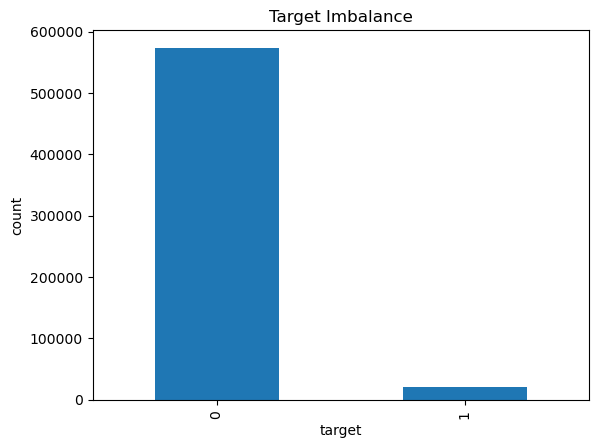

In [7]:
plt.figure()
df['target'].value_counts().plot(kind='bar')
plt.title("Target Imbalance")
plt.xlabel("target")
plt.ylabel("count")
plt.show()


In [8]:
# Correlation with target (quick look)
print(df.corr()['target'].sort_values(ascending=False).head(10))

target           1.000000
ps_car_13        0.053899
ps_car_12        0.038790
ps_ind_17_bin    0.037053
ps_reg_02        0.034800
ps_ind_07_bin    0.034218
ps_car_04_cat    0.032900
ps_car_03_cat    0.032401
ps_reg_03        0.030888
ps_ind_05_cat    0.029165
Name: target, dtype: float64


In [12]:
# 5. PREPROCESSING & FEATURE SETUP

In [9]:
# Drop ID
df = df.drop(columns=['id'])
X = df.drop("target", axis=1)
y = df["target"]


In [ ]:
# Train/Test split (stratified)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# SCALING

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
# 6. HANDLE CLASS IMBALANCE (SMOTE)

In [12]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [ ]:
# 7. Baseline Models

In [13]:
# Logistic Regression

lr = LogisticRegression(class_weight='balanced', max_iter=1000)


In [14]:
lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [15]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


In [16]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [18]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,   # 1 important
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [19]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.05, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=6, max_leaves=0,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=500, n_jobs=-1, num_parallel_tree=1,
              predictor='auto', random_state=42, reg_alpha=0, reg_lambda=1, ...)

In [ ]:
# 8. Get probabilities

In [20]:
lr_prob = lr.predict_proba(X_test_scaled)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
xgb_prob = xgb.predict_proba(X_test)[:,1]


In [21]:
xgb_prob

array([0.54646856, 0.50410295, 0.2998817 , ..., 0.5247307 , 0.42581958,
       0.43376774], dtype=float32)

In [ ]:
# Check Best Threshold

In [22]:
for t in [0.4, 0.5, 0.6, 0.7]:
    y_pred = (xgb_prob > t).astype(int)

    from sklearn.metrics import recall_score, precision_score
    
    print(f"Threshold: {t}")
    print("Recall:", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print()

Threshold: 0.4
Recall: 0.7275870016132749
Precision: 0.04609835874072776

Threshold: 0.5
Recall: 0.4404240608435123
Precision: 0.058134582623509366

Threshold: 0.6
Recall: 0.1885227010831989
Precision: 0.07698823529411765

Threshold: 0.7
Recall: 0.049781055542751786
Precision: 0.10369659145463274



In [ ]:
# 9. Apply threshold

In [23]:
threshold = 0.5

lr_pred = (lr_prob > threshold).astype(int)
rf_pred = (rf_prob > threshold).astype(int)
xgb_pred = (xgb_prob > threshold).astype(int)

In [ ]:
# 10. Calculate metrics

In [24]:
from sklearn.metrics import recall_score, precision_score

print("LR Recall:", recall_score(y_test, lr_pred))
print("RF Recall:", recall_score(y_test, rf_pred))
print("XGB Recall:", recall_score(y_test, xgb_pred))

print("\nXGB Precision:", precision_score(y_test, xgb_pred))

LR Recall: 0.5464392717215948
RF Recall: 0.0
XGB Recall: 0.4404240608435123

XGB Precision: 0.058134582623509366


In [ ]:
# 11. Final comparison table

In [25]:
from sklearn.metrics import roc_auc_score, average_precision_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ],
    "Avg Precision": [
        average_precision_score(y_test, lr_prob),
        average_precision_score(y_test, rf_prob),
        average_precision_score(y_test, xgb_prob)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ]
})

print(results)

                 Model   ROC-AUC  Avg Precision    Recall
0  Logistic Regression  0.623246       0.058763  0.546439
1        Random Forest  0.595189       0.053625  0.000000
2              XGBoost  0.622787       0.062560  0.440424


In [ ]:
# 12. Check Important Feature

In [26]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(10))


          Feature  Importance
16  ps_ind_17_bin    0.053930
5   ps_ind_06_bin    0.053689
27  ps_car_07_cat    0.039640
4   ps_ind_05_cat    0.035332
23  ps_car_03_cat    0.028059
15  ps_ind_16_bin    0.026164
34      ps_car_13    0.022763
8   ps_ind_09_bin    0.021697
6   ps_ind_07_bin    0.021622
2       ps_ind_03    0.020026


In [ ]:
# 13. Show Confusion Matrix

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_pred)
print(cm)

[[83743 30961]
 [ 2428  1911]]


In [ ]:
# 15. Plot ROC Curve (Visualization)

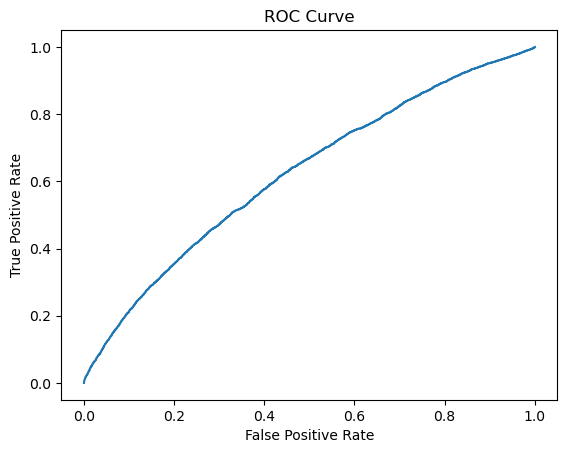

In [28]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, xgb_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
# 16. Feature Importance

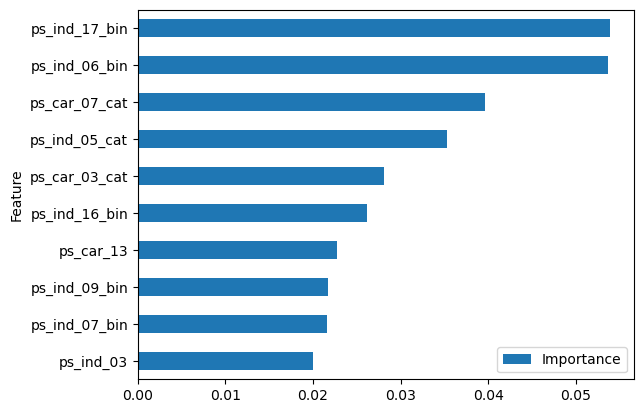

In [29]:
importance.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# 17. Save Model

In [31]:
import joblib
joblib.dump(xgb, "insurance_model.pkl")

['insurance_model.pkl']

In [ ]:
# 18. Create Simple Prediction Function

In [33]:
def predict_customer(data):
    # Step 1: get probability
    prob = xgb.predict_proba(data)[:, 1]
    
    # Step 2: apply threshold
    threshold = 0.5
    pred = (prob > threshold).astype(int)
    
    return {
        "prediction": pred,
        "probability": prob
    }